# Building a SolarFarmer API payload

This notebook demonstrates how to define a SolarFarmer API payload using the **validated data models** shipped in `solarfarmer.models`.

The top-level `EnergyCalculationInputs` model is the single entry point for running calculations — all sub-models are nested directly inside it, and serialization to camelCase JSON is handled automatically.

**Model highlights:**

| Aspect | Description |
|---|---|
| Field names | snake_case (Pythonic), auto-aliased to camelCase on serialization |
| Validation | Automatic on construction — invalid fields raise `ValidationError` immediately |
| Assembly | Direct model composition (`EnergyCalculationInputs`, `PVPlant`, etc.) |
| Serialization | `model.model_dump_json(by_alias=True, exclude_none=True)` |
| Immutability | Frozen by default (except `EnergyCalculationOptions`) |

See related SolarFarmer public documentation:
- [Acquiring API key](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Introduction/ApiKey.html)
- [API data model reference](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/)
- [ModelChain endpoint](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Endpoints/ModelChainEndpoint.html)
- [API Validation Service](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Troubleshooting/ValidationService.html)

## 0. Prerequisites

**Notebook Information:**
- **Last Updated:** May 2026
- **Written for:** SolarFarmer SDK v0.3.0+
- [View latest version in repository](https://github.com/dnv-opensource/solarfarmer-python-sdk/blob/main/docs/notebooks/Example_Compose_Plant.ipynb)

### 0.1 Install the SolarFarmer Python SDK

This notebook requires the SolarFarmer Python SDK to be installed. Install it via pip:

```bash
pip install dnv-solarfarmer
```

In [1]:
import os
from pprint import pprint
from pathlib import Path

import solarfarmer as sf
from solarfarmer.models import (
    EnergyCalculationInputs,
    EnergyCalculationOptions,
    Inverter,
    Layout,
    Location,
    MonthlyAlbedo,
    MountingTypeSpecification,
    PVPlant,
    TrackerSystem,
    Transformer,
    TransformerSpecification,
    TransformerLossModelTypes,
)

# Check SDK version compatibility
NOTEBOOK_MIN_SDK_VERSION = "0.3.0"

print(f"SolarFarmer Python SDK v{sf.__version__}")

def parse_version(v):
    """Simple version parser for x.y.z format"""
    return tuple(map(int, v.split('.')))

try:
    if parse_version(sf.__version__) < parse_version(NOTEBOOK_MIN_SDK_VERSION):
        print(f"\n    WARNING: This notebook requires SDK v{NOTEBOOK_MIN_SDK_VERSION} or later.")
        print(f"    Your version: {sf.__version__}")
        print(f"    Some examples may not work correctly.")
        print(f"    Upgrade with: pip install --upgrade solarfarmer\n")
except Exception:
    pass

sf.configure_logging();

SolarFarmer Python SDK v0.3.0


### 0.2 API Key Required

You need a SolarFarmer API key to run energy calculations. Instructions for acquiring one is [HERE](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Introduction/ApiKey.html)

**Important:** Avoid hardcoding your API key directly in notebook cells.

- **Use environment variables (Recommended):**

  The SDK automatically uses the `SF_API_KEY` environment variable. Set it in your terminal before starting Jupyter:

  **Linux/Mac:**
  ```bash
  export SF_API_KEY="your-key-here"
  ```

  **Windows:**
  ```bash
  set SF_API_KEY=your-key-here
  ```

- **Entering your API key (Alternative):**

  This notebook will prompt you to enter your API key and keep it hidden from view.

> **Note:** An API key is not required to build and validate a payload with Pydantic models. It is only needed if you intend to submit the payload to a SolarFarmer energy calculation endpoint.

In [2]:
if os.getenv("SF_API_KEY") is None:
    print("WARNING: `SF_API_KEY` environment variable not set.")
    import getpass
    api_key = getpass.getpass("Enter your SolarFarmer API key: ")
    print("Using API key entered by user.\n")
else:
    api_key = os.getenv("SF_API_KEY")
    print("Using API key from environment variable `SF_API_KEY`\n")

Using API key from environment variable `SF_API_KEY`



## 1. Definition of SolarFarmer API Data Model Components

The data models in `solarfarmer.models` mirror the [ModelChain API payload schema](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/) directly. Each model uses **snake_case** field names for a Pythonic developer experience, with automatic **camelCase** alias generation for API serialization.

All models inherit from `SolarFarmerBaseModel`, which provides:
- **camelCase aliases** — `model_dump(by_alias=True)` produces API-ready JSON
- **Frozen instances** — models are immutable after construction (except `EnergyCalculationOptions`)
- **Automatic validation** — Pydantic validates field types, ranges and constraints on construction

| Class | Purpose | API docs |
|---|---|---|
| `Location` | Site coordinates (latitude, longitude, altitude) | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Location.html) |
| `MonthlyAlbedo` | 12 monthly ground reflectance values | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.MonthlyAlbedo.html) |
| `EnergyCalculationOptions` | Modelchain options and output configuration | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.EnergyCalculationOptions.html) |
| `TransformerSpecification` | Loss model and parameters for the transformer | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.TransformerSpecification.html) |
| `MountingTypeSpecification` | Rack/tracker mounting geometry and thermal parameters | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.MountingTypeSpecification.html) |
| `TrackerSystem` | Tracker rotation limits, backtracking and terrain alignment | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.TrackerSystem.html) |
| `Layout` | PV array configuration within an inverter input | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Layout.html) |
| `Inverter` | Inverter and its associated array layouts | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Inverter.html) |
| `Transformer` | Wraps one or more inverters; can be multiplied | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Transformer.html) |
| `PVPlant` | Electrical topology grouping all specs and hierarchy | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.PVPlant.html) |
| `EnergyCalculationInputs` | Top-level payload composing all of the above | — |

The sections below walk through defining each component individually before composing them into a complete `EnergyCalculationInputs` payload.

### 1.1 Location, albedo and calculation options

Define the site location, monthly ground reflectance (albedo), and energy calculation options.

The `Location` model validates that latitude is in [-90, 90] and longitude is in [-180, 180]. Constructing a `Location` with invalid values will raise a `ValidationError` immediately.

| Class | Contents | API docs |
|---|---|---|
| `Location` | Latitude, longitude and altitude of the site | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Location.html) |
| `MonthlyAlbedo` | 12 monthly ground reflectance values | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.MonthlyAlbedo.html) |
| `EnergyCalculationOptions` | Modelchain options and output configuration | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.EnergyCalculationOptions.html) |

In [3]:
# Constructing a Location with invalid values raises a ValidationError immediately:
from pydantic import ValidationError

try:
    invalid_location = Location(
        latitude=1234,      # invalid: must be in [-90, 90]
        longitude=9943.21,  # invalid: must be in [-180, 180]
        altitude=123,
    )
except ValidationError as e:
    print("ValidationError caught on construction:\n")
    print(e)

ValidationError caught on construction:

2 validation errors for Location
longitude
  Input should be less than or equal to 180 [type=less_than_equal, input_value=9943.21, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal
latitude
  Input should be less than or equal to 90 [type=less_than_equal, input_value=1234, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal


In [4]:
monthly_albedo = MonthlyAlbedo(values=[0.2] * 12)       # 12 monthly ground reflectance values
calculation_options = EnergyCalculationOptions(
    diffuse_model="Perez",
    include_horizon=False,
)    

print("=" * 90)
pprint(calculation_options.model_dump(), sort_dicts=False, compact=True, width=100)
print("=" * 90)

{'diffuse_model': 'Perez',
 'include_horizon': False,
 'calculation_year': 1990,
 'default_wind_speed': 0.0,
 'calculate_dhi': False,
 'apply_diffuse_to_horizon': None,
 'horizon_type': None,
 'treat_circumsolar_as_direct': True,
 'use_most_shaded_cell_for_diffuse': False,
 'model_back_row_separately': True,
 'apply_iam': True,
 'apply_spectral_mismatch_modifier': False,
 'include_module_performance': True,
 'include_cell_temperature_model': True,
 'include_soiling_loss_in_temperature_model': True,
 'use_iam_for_temperature_model': True,
 'include_array_iv': True,
 'include_inverter_model': True,
 'include_ac_model': True,
 'system_availability_loss': 0.0,
 'grid_availability_loss': 0.0,
 'add_tare_loss_to_inverter_efficiency_model': False,
 'ignore_low_power_point_in_efficiency_data': False,
 'solar_measurement_plane_azimuth': 0.0,
 'solar_measurement_plane_tilt': 0.0,
 'solar_zenith_angle_limit': 88.0,
 'missing_met_data_handling': None,
 'return_pv_syst_format_time_series_results': 

For this example, we will request that additional detailed calculation results are returned by the API so we can examine them later in this notebook.

> **Note:** `EnergyCalculationOptions` is the one Pydantic model that is mutable (`frozen=False`), so fields can be updated after construction.

In [5]:
calculation_options.return_detailed_time_series_results = True
calculation_options.return_pv_syst_format_time_series_results = True
calculation_options.return_loss_tree_time_series_results = True

### 1.2 Component specifications

Define the reusable specification objects that describe how equipment is configured. Each is stored in a named dictionary so it can be referenced by ID later in the plant hierarchy.

| Class | Purpose | API docs |
|---|---|---|
| `TransformerSpecification` | Loss model and parameters for the transformer | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.TransformerSpecification.html) |
| `MountingTypeSpecification` | Rack/tracker mounting geometry, thermal coefficients and soiling | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.MountingTypeSpecification.html) |
| `TrackerSystem` | Tracker rotation limits, backtracking settings and terrain alignment | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.TrackerSystem.html) |

In [6]:
transformer_spec = TransformerSpecification(
    model_type=TransformerLossModelTypes.SIMPLE_LOSS_FACTOR,
    loss_factor=0.01,  # 1%
)
transformer_specs = {"TransformerSpec1": transformer_spec}

print("=" * 90)
pprint({k: v.model_dump() for k, v in transformer_specs.items()}, sort_dicts=False, compact=True, width=100)
print("=" * 90)

{'TransformerSpec1': {'model_type': 'SimpleLossFactor',
                      'loss_factor': 0.01,
                      'rated_power': None,
                      'no_load_loss': None,
                      'full_load_ohmic_loss': None}}


#### 1.2.1 Mounting specification

Defines the physical rack or tracker geometry and thermal model:

- **Module geometry** — orientation (portrait/landscape), modules per row/column, frame dimensions
- **Thermal model** — constant and convective heat transfer coefficients
- **Bifacial parameters** — transmission factor, shade and mismatch loss factors
- **Soiling** — 12 monthly loss values

> **Note:** Field names use snake_case (e.g., `bifacial_mismatch_loss_factor` instead of `bifacialMismatchLossFactor`). Pydantic auto-generates camelCase aliases for API serialization.

In [7]:
mounting = MountingTypeSpecification(
    bifacial_mismatch_loss_factor=0.01,
    bifacial_shade_loss_factor=0.02,
    constant_heat_transfer_coefficient=25,
    convective_heat_transfer_coefficient=1.2,
    frame_bottom_width=0.0,
    frame_end_width=0.0,
    frame_top_width=0.0,
    height_of_tracker_center_from_ground=2,
    is_tracker=True,
    modules_are_landscape=False,          # portrait orientation
    monthly_soiling_loss=[0.01] * 12,     # 1% for all months
    number_of_modules_high=1,             # single portrait row
    rack_height=1.96,                     # same as module height from PAN file (m)
    transmission_factor=0.05,
    y_spacing_between_modules=0,
)
mounting_specs = {"MountingSpec1": mounting}

print("=" * 90)
pprint({k: v.model_dump() for k, v in mounting_specs.items()}, sort_dicts=False, compact=True, width=100)
print("=" * 90)

{'MountingSpec1': {'is_tracker': True,
                   'number_of_modules_high': 1,
                   'modules_are_landscape': False,
                   'rack_height': 1.96,
                   'y_spacing_between_modules': 0.0,
                   'frame_bottom_width': 0.0,
                   'constant_heat_transfer_coefficient': 25.0,
                   'convective_heat_transfer_coefficient': 1.2,
                   'monthly_soiling_loss': [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
                                            0.01, 0.01, 0.01],
                   'number_of_modules_long': None,
                   'x_spacing_between_modules': None,
                   'frame_top_width': 0.0,
                   'frame_end_width': 0.0,
                   'tilt': None,
                   'height_of_lowest_edge_from_ground': None,
                   'height_of_tracker_center_from_ground': 2.0,
                   'transmission_factor': 0.05,
                   'bifacial_shade_lo

#### 1.2.2 Tracker system

Defines the single-axis tracker kinematics and terrain alignment:

- **Rotation limits** — minimum and maximum rotation angles
- **Terrain** — system plane azimuth and tilt for sloped terrain
- **Backtracking** — enable/disable backtracking and slope-aware backtracking
- **GCR** — east-west ground coverage ratio used for backtracking rotation calculations

In [8]:
tracker = TrackerSystem(
    is_backtracking=True,
    rotation_min_deg=-60,
    rotation_max_deg=60,
    system_plane_azimuth=0,   # flat terrain
    system_plane_tilt=0,      # flat terrain
)
tracker_specs = {"TrackerSpec1": tracker}

print("=" * 90)
pprint({k: v.model_dump() for k, v in tracker_specs.items()}, sort_dicts=False, compact=True, width=100)
print("=" * 90)

{'TrackerSpec1': {'system_plane_azimuth': 0.0,
                  'system_plane_tilt': 0.0,
                  'rotation_min_deg': -60.0,
                  'rotation_max_deg': 60.0,
                  'tracker_azimuth': None,
                  'east_west_gcr': None,
                  'is_backtracking': True,
                  'use_slope_aware_backtracking': None}}


### 1.3 Plant hierarchy: layout → inverter → transformer

Components are assembled bottom-up into a nested hierarchy. Each level can contain multiple instances of the level below:

| Class | Purpose | API docs |
|---|---|---|
| `Layout` | PV array characteristics for a given inverter input; each difference in array configuration requires a separate layout | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Layout.html) |
| `Inverter` | Wraps one or more layouts; can be multiplied by the number of identical inverters on site | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Inverter.html) |
| `Transformer` | Wraps one or more inverters; can be multiplied by the number of identical transformers on site | [docs](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/webApiRef/SolarFarmerApi.Client.Transformer.html) |

#### 1.3.1 Layout

In [9]:
layout = Layout(
    azimuth=180,                                             # south-facing
    dc_ohmic_connector_loss=0.015,                           # 1.5%
    inverter_input=[0],                                      # 0-indexed MPPT input
    is_trackers=True,
    layout_count=1,
    module_mismatch_loss=0.005,                              # 0.5%
    module_quality_factor=0.01,                              # 1%
    module_specification_id="CanadianSolar_CS6U-330M_APP",   # must match PAN filename
    mounting_type_id="MountingSpec1",                        # must match a mounting spec key
    name="LayoutSpec1",
    number_of_strings_in_left_row=1,
    number_of_strings_in_right_row=1,
    pitch=10,
    string_length=30,                                        # modules; Vmp ≈ 960 V at 50 °C
    terrain_azimuth=0,
    terrain_slope=0,
    total_number_of_strings=14,                              # 14 × 30 × 330 W = 138.6 kW DC
    tracker_system_id="TrackerSpec1",                        # must match a tracker spec key
)

#### 1.3.2 Inverter

Wraps one or more layouts into a single inverter instance:

In [10]:
inverter = Inverter(
    ac_wiring_ohmic_loss=0.005,                      # 0.5%
    inverter_count=1,
    inverter_spec_id="Sungrow_SG125HV_APP",          # must match OND filename
    layouts=[layout],
    name="InverterSpec1",
)

#### 1.3.3 Transformer

Wraps one or more inverters. `transformer_count` multiplies the instance across identical transformers on site.

In [11]:
transformer = Transformer(
    inverters=[inverter],
    transformer_count=1,
    transformer_spec_id="TransformerSpec1",  # must match a transformer spec key
)

print("Transformer wraps Inverter and Layout:")
print("=" * 90)
pprint(transformer.model_dump(), sort_dicts=False, compact=True, width=100)
print("=" * 90)

Transformer wraps Inverter and Layout:
{'transformer_count': 1,
 'inverters': [{'inverter_spec_id': 'Sungrow_SG125HV_APP',
                'inverter_count': 1,
                'layouts': [{'layout_count': 1,
                             'module_specification_id': 'CanadianSolar_CS6U-330M_APP',
                             'mounting_type_id': 'MountingSpec1',
                             'is_trackers': True,
                             'azimuth': 180.0,
                             'pitch': 10.0,
                             'total_number_of_strings': 14,
                             'string_length': 30,
                             'inverter_input': [0],
                             'dc_ohmic_connector_loss': 0.015,
                             'module_mismatch_loss': 0.005,
                             'name': 'LayoutSpec1',
                             'tracker_system_id': 'TrackerSpec1',
                             'number_of_strings_in_front_row': 0,
                             

### 1.4 Composing the `PVPlant` model

The `PVPlant` model groups the plant hierarchy and specification libraries into a single typed structure with validated fields:

- `pv_plant.transformers` — the electrical hierarchy (transformers → inverters → layouts)
- `pv_plant.mounting_type_specifications` — rack/tracker mounting geometry and thermal parameters
- `pv_plant.tracker_systems` — tracker rotation limits and backtracking settings
- `pv_plant.transformer_specifications` — transformer loss models

In [12]:
pv_plant = PVPlant(
    transformers=[transformer],
    mounting_type_specifications=mounting_specs,
    tracker_systems=tracker_specs,
    transformer_specifications=transformer_specs,
)

## 2. Composing `EnergyCalculationInputs`

With all components defined, `EnergyCalculationInputs` composes them into a single validated payload using direct model composition and built-in serialization.

### 2.1 Inspecting the JSON payload

Use `model_dump_json(by_alias=True)` to produce camelCase JSON matching the API schema.

In [13]:
# Build a valid payload for inspection (using a placeholder location for now)
valid_location = Location(latitude=46.95, longitude=7.37, altitude=575)  # Bern, Switzerland

inputs = EnergyCalculationInputs(
    location=valid_location,
    pv_plant=pv_plant,
    monthly_albedo=MonthlyAlbedo.from_list([0.2] * 12),
    energy_calculation_options=calculation_options,
)

payload_json = inputs.model_dump_json(by_alias=True, exclude_none=True, indent=2)
print("=" * 90)
print(payload_json)
print("=" * 90)

{
  "location": {
    "longitude": 7.37,
    "latitude": 46.95,
    "altitude": 575.0
  },
  "pvPlant": {
    "transformers": [
      {
        "transformerCount": 1,
        "inverters": [
          {
            "inverterSpecID": "Sungrow_SG125HV_APP",
            "inverterCount": 1,
            "layouts": [
              {
                "layoutCount": 1,
                "moduleSpecificationID": "CanadianSolar_CS6U-330M_APP",
                "mountingTypeID": "MountingSpec1",
                "isTrackers": true,
                "azimuth": 180.0,
                "pitch": 10.0,
                "totalNumberOfStrings": 14,
                "stringLength": 30,
                "inverterInput": [
                  0
                ],
                "dcOhmicConnectorLoss": 0.015,
                "moduleMismatchLoss": 0.005,
                "name": "LayoutSpec1",
                "trackerSystemID": "TrackerSpec1",
                "numberOfStringsInFrontRow": 0,
                "numberOfStrin

### 2.2 Saving the payload to file

Write the JSON payload to a file. With Pydantic, this is a simple file write of the serialized JSON string.

In [14]:
output_file = Path("EnergyCalcInputs_Pydantic.json")
output_file.write_text(inputs.model_dump_json(by_alias=True, exclude_none=True, indent=2))
print(f"Payload saved to: {output_file.absolute()}")

Payload saved to: c:\repos\solarfarmer-python-sdk-github\docs\notebooks\EnergyCalcInputs_Pydantic.json


### 2.3 Validation

Validation is **automatic** — it happens at construction time.

If all models constructed without raising a `ValidationError`, the payload is structurally valid. A more thorough server-side validation still occurs when the payload is submitted to the [API Validation Service](https://mysoftware.dnv.com/download/public/renewables/solarfarmer/manuals/latest/WebApi/Troubleshooting/ValidationService.html).

In [15]:
# If we got here with a valid `inputs` object, the payload is valid.
print("The Pydantic-composed payload is valid and ready for API calls.")
print(f"  Location:     ({inputs.location.latitude}, {inputs.location.longitude})")
print(f"  Transformers: {len(inputs.pv_plant.transformers)}")
print(f"  Albedo:       {inputs.monthly_albedo.values[:3]}... (12 values)")

The Pydantic-composed payload is valid and ready for API calls.
  Location:     (46.95, 7.37)
  Transformers: 1
  Albedo:       [0.2, 0.2, 0.2]... (12 values)


## 3. Running an energy calculation with a Pydantic-composed payload

The `EnergyCalculationInputs` instance can be passed directly to `run_energy_calculation()` via the `plant_builder` parameter — no manual serialization required.

### 3.1 Sample data

This section of the notebook uses sample input files (meteorological data, PAN and OND files).

**Download the sample data:**

Clone the full repository:
```bash
git clone https://github.com/dnv-opensource/solarfarmer-python-sdk.git
```

Or download the `docs/notebooks/sample_data/` folder directly from the [repository](https://github.com/dnv-opensource/solarfarmer-python-sdk/):

Update `sample_data_dir` to where the data is located on your system.


In [16]:
sample_data_dir = Path("sample_data")

if not sample_data_dir.exists():
    print(f"WARNING: Sample data not found at: {sample_data_dir.absolute()}")
    print("Download it from: https://github.com/AkerBP/solarfarmer-api-python-sdk")
else:
    print(f"Sample data found at: {sample_data_dir.absolute()}")

    # A folder with all required modelchain inputs (JSON, PAN, OND, meteorological data)
    folder_with_inputs = sample_data_dir / "Inputs_Bern_2D_racks"

Sample data found at: /home/iantse/git_repos/solarfarmer-python-sdk/docs/notebooks/sample_data


### 3.2 Running the calculation

The `inputs` object created in §2.1 already uses the Bern, Switzerland location with validated coordinates, so it is ready to submit.

In [17]:
print("Valid location for Bern, Switzerland:")
print("=" * 90)
pprint(inputs.location.model_dump(), sort_dicts=False, compact=True, width=50)
print("=" * 90)

Valid location for Bern, Switzerland:
{'longitude': 7.37,
 'latitude': 46.95,
 'altitude': 575.0}


In [18]:
# Save the payload for use with run_energy_calculation()
output_file_bern = Path("EnergyCalcInputs_Bern_Pydantic.json")
output_file_bern.write_text(inputs.model_dump_json(by_alias=True, exclude_none=True, indent=2))
print(f"Payload saved to: {output_file_bern.absolute()}")

Payload saved to: /home/iantse/git_repos/solarfarmer-python-sdk/docs/notebooks/EnergyCalcInputs_Bern_Pydantic.json


### 3.3 Submitting to the ModelChain endpoint

Pass the `EnergyCalculationInputs` instance directly to `run_energy_calculation()` via the `plant_builder` parameter. The `module_specification_id` (`"CanadianSolar_CS6U-330M_APP"`) and `inverter_spec_id` (`"Sungrow_SG125HV_APP"`) must match the PAN and OND filenames.

> **Note** — this cell makes a live HTTPS request to the SolarFarmer API and requires a valid `api_key` set in §0.2.


In [19]:
results = sf.run_energy_calculation(
    api_key=api_key,
    plant_builder=inputs,
    pan_file_paths=[folder_with_inputs / "CanadianSolar_CS6U-330M_APP.PAN"],
    ond_file_paths=[folder_with_inputs / "Sungrow_SG125HV_APP.OND"],
    meteorological_data_file_path=folder_with_inputs / "Bern-hour.dat",
    project_id="Pydantic compose example",
    print_summary=True,
    save_outputs=False,
)


INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 07-05-2026 14:49:42
INFO: SUCCESS: Calculation returned successfully (time taken: 11.2 seconds)


-------------------------------------------------------
		General site data:
-------------------------------------------------------
Project name = Pydantic compose example
Location (latitude, longitude, altitude) = 46.95000°, 7.37000°, 575.0 m
2D/3D = 2D calculation
Mounting type = Single-axis trackers
AC capacity of system = 0.125 MW
DC capacity of system = 0.1386 MW
Run in SolarFarmer API version 6.1.0
-------------------------------------------------------
    Annual Performance Summary (project year 1, 1990)
-------------------------------------  ---------------
Average annual temperature             10.61°C
Horizontal irradiation                 1192.73 kWh/m²
Irradiation on tilted plane            1604.46 kWh/m²
Effective irradiation on tilted plane  1533.93 kWh/m²
Energy yield                           1363.69 kWh/kWp
Net energy                             189.01 MWh/year
Performance Ratio                      0.8499
-------------------------------------  ---------------


### 3.4 Accessing the results

`run_energy_calculation()` returns a `CalculationResults` object. Use `print_annual_results()` for a summary table, or access data directly via attributes such as `results.AnnualData`, `results.MonthlyData`, `results.PVsystTimeseries`, and `results.LossTreeTimeseries`.

For a full walkthrough of the results object and its properties, see the **`Example_EnergyCalculations`** notebook.


In [20]:
results.print_annual_results()

----------------------------------------
Annual Results Summary (Years: 1 (1990))
----------------------------------------
Property                     Units       Year 1
                                         (1990)
---------------------------  --------  --------
Energy yield                 kWh/kWp    1363.69
Net energy                   MWh/year    189.01
Production DC                kWh         195086
Production AC                kWh         191483
Performance Ratio            %            84.99
Performance Ratio Bifacial   %            84.99
Average annual temperature   °C           10.61
Horizontal irradiation       kWh/m²     1192.73
Irradiation on tilted plane  kWh/m²     1604.46
GI with horizon              kWh/m²     1604.46
Global effective irradiance  kWh/m²     1533.93
Gain on tilted plane         %            34.52
----------------------------------------
Annual Effects Summary (Years: 1 (1990))
----------------------------------------
Effect (%)                        

Since we configured `return_pv_syst_format_time_series_results = True`, we can use `pvsyst_timeseries()` to access a table of hourly calculation data

In [21]:
df_pvsyst = results.pvsyst_timeseries()
df_pvsyst.head()

,Alb_Inc,Albedo,Aux_Lss,AzSol,BackNearShd,BackShd,BeamHor,BeamInc,BmIncBk,DiffHor,...,ShdLossTotal,SlgLoss,SpctCor,T_Amb,TArray,TempLss,U_Boost,UArray,UnavLss,WindVel
date,,,,,,,,,,,,,,,,,,,,,
1990-01-01 00:00:00,0.0,0.2,0,177.845,0,0,0,0.0,0,0,...,0.0,0.0,0,8.0,8.0,0.0,0,0.0,0,0.5
1990-01-01 01:00:00,0.0,0.2,0,-149.894,0,0,0,0.0,0,0,...,0.0,0.0,0,7.8,7.8,0.0,0,0.0,0,0.2
1990-01-01 02:00:00,0.0,0.2,0,-125.682,0,0,0,0.0,0,0,...,0.0,0.0,0,7.6,7.6,0.0,0,0.0,0,0.1
1990-01-01 03:00:00,0.0,0.2,0,-108.687,0,0,0,0.0,0,0,...,0.0,0.0,0,7.5,7.5,0.0,0,0.0,0,0.4
1990-01-01 04:00:00,0.0,0.2,0,-95.717,0,0,0,0.0,0,0,...,0.0,0.0,0,7.5,7.5,0.0,0,0.0,0,0.4


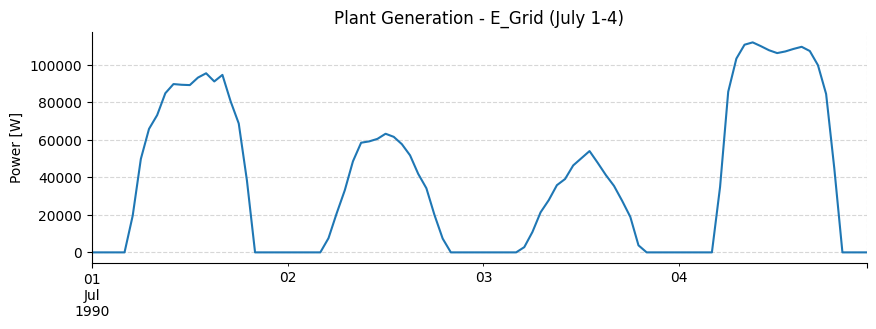

In [22]:
ax = df_pvsyst.loc["1990-07-01":"1990-07-04", "E_Grid"].plot(
    figsize=(10, 3),
    title="Plant Generation - E_Grid (July 1-4)",
    ylabel="Power [W]",
    xlabel="",
    linewidth=1.5,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False);

Likewise, since we set `return_loss_tree_time_series_results = True`, we can use `loss_tree_timeseries()` to access a table of hourly loss and gain effects in processing order.

In [23]:
df_losstree = results.loss_tree_timeseries()

df_losstree.loc["1990-07-01 12:00"]

FromGHI                                                    625.527
FromPOAIrradiance                                          626.175
FromPOAIrradianceIncludingHorizon                          626.175
FromPOAIrradianceIncBeamShading                            626.175
FromPOAIrradianceIncSkyDiffuseShading                      626.173
FromPOAIrradianceIncReflectedBeamShading                   626.164
FromPOAIrradianceIncReflectedDiffuseShading                626.164
FromPOAIrradianceIncludingSoiling                          619.902
FromPOAIrradianceIncludingIAM                              612.801
FromPOAIrradianceIncludingSpectral                         612.801
FromPOAIrradianceIncBifacialGain                           612.801
FromPOAIrradianceIncBackNearShading                        612.801
FromPOAIrradianceIncBifacialAngular                        612.801
FromPOAIrradianceIncBifacialShading                        612.801
FromPOAIrradianceIncTransmissionFactor                     612